# Финальный проект модуля Python
#  «Анализ данных об оптовых продажах аудиотехники»

**В финальном проекте модуля Python вам предстоит поработать аналитиком данных в компании «Карпов Саунд», которая занимается оптовой продажей аудиотехники и предлагает широкий ассортимент товаров от ведущих мировых брендов, включающий профессиональные аудиосистемы, домашние кинотеатры, портативные аудиоустройства и прочие аксессуары.** 

«Карпов Саунд» сотрудничает с крупными розничными сетями и специализированными магазинами аудиотехники в России. Клиенты компании регулярно оставляют заявки на закупку товаров в CRM системе, менеджеры связываются с клиентами, обсуждают детали, после чего заказы либо подтверждаются менеджерами, либо по разным причинам отменяются. 

В «Карпов Саунд» трепетно относятся к хранению информации о своих товарах, клиентах и заказах, однако в самый неподходящий момент хранилище данных компании оказалось временно недоступно из-за плановых работ по его оптимизации. Поэтому в рамках этого проекта все данные будут представлены не в самом удобном для анализа виде — в формате резервной выгрузки, разложенной по разным папкам на сервере компании.

Вам необходимо собрать данные из разрозненных источников, проанализировать их и сделать выводы, которые помогут руководству компании принять верные тактические решения.

**В ходе работы над проектом вам встретятся следующие таблицы:**  

1) orders (данные о заказах):  
- order_id — номер заказа  
- product_id — идентификатор товара  
- quantity — количество этого товара в заказе

2) order_status (данные о статусах заказов и клиентах):
- order_id — номер заказа  
- client_id — идентификатор клиента  
- status — статус заказа

3) products (данные о товарах):
- id — идентификатор товара  
- name — имя товара (сначала указан бренд, через запятую модель товара)  
- price — цена единицы товара, в долларах

Каждый заказ имеет статус или подтвержденного (`confirmed`), или отмененного (`canceled`). В одном заказе может быть несколько разных товаров. Если заказ был отменен, а потом создан такой же (тем же клиентом, с теми же товарами, у того же менеджера), в базе останется запись о двух заказах с разными номерами и статусами, поскольку система не позволяет создать заказ с тем же номером.

Сначала вам нужно собрать и предобработать три типа датасетов: `orders.csv`, `order_status.csv`, `products.csv`.

На схеме показано, как связаны таблицы между собой:

![](https://storage.yandexcloud.net/klms-public/production/learning-content/457/4167/37264/104636/497986/er_white.png)

Данные находятся в папке `data` из директории `shared` (`shared` -> `homeworks` -> `python_ds_miniprojects` -> `final_project`). Внутри папки `data` находятся 2 другие папки: `orders` и `products`.

В папке `orders` папки с датами, в которые сделаны записи. В этих папках — папки с именами менеджеров по продажам. Эти папки содержат файлы `orders.csv` и `order_status.csv` (в каждой папке по одной паре файлов). Пример структуры: `data` -> `orders` -> `2024-03-01` -> `Алексей Саксофонов` -> `orders.csv` и `order_status.csv`.

В папке `products` папки с категориями товаров. В этих папках файлы `products.csv` (в каждой папке по одному файлу). Пример структуры: `data` -> `products` -> `AV-процессор` -> `products.csv`.

Кроме того у вас есть файл `usd_rate.txt` с курсом доллара США на каждый день анализируемого периода (данные в формате `дата,курс,валюта`). Он потребуется в середине проекта.

В финальном проекте модуля вы можете пользоваться подсказками в ноутбуке (они менее подробные, чем были в предыдущих уроках), обращаться за помощью к экспертам в Discord и смотреть разборы в LMS (за просмотр разбора снимается половина баллов за задание).

### Соберем датасет с заказами по папкам

## Шаг 2

**Ваша первая задача — собрать данные со всех папок в три датафрейма:**  
1. `df_orders` — на основе датасетов `orders.csv` + добавьте колонку `manager` с именами менеджеров и колонку `date` с датами. Отсортируйте датафрейм по возрастанию `order_id` и `product_id`.
2. `df_order_status` — на основе датасетов `order_status.csv`. Отсортируйте датафрейм по возрастанию `order_id`. 
3. `df_products` — на основе датасетов `products.csv` + добавьте колонку `category` с категориями товаров. Отсортируйте датафрейм по возрастанию `id`.  

**Соберите датафреймы и сохраните их в соответствующие csv файлы: `df_orders.csv`, `df_order_status.csv` и `df_products.csv`. Отправьте файлы на проверку в LMS.**

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) Импортируйте библиотеки `pandas` и `os`.  
      
2) По аналогии с кодом, который вы использовали для сбора данных в 7-м уроке про грязные данные, сделайте следующее:  
a. создайте путь к папке `data`, используя ваш логин;  
b. соберите названия нужных вам файлов (`orders.csv`, `order_status.csv`, `products.csv`) в список `target_files`;  
c. создайте пустой список `data_files`, куда будете сохранять пути к файлам;  
d. с помощью функции `os.walk()` создайте генератор;  
e. с помощью цикла пройдитесь по генератору и, если название файла совпадает с нужным вам из списка `target_files`, путь к этому файлу добавьте в список `data_files`.
      
3) Используя пути к файлам из списка `data_files`, соберите полные датафреймы `df_orders`, `df_order_status` и `df_products`:  
a. создайте пустые списки `orders_df_list`, `order_status_df_list` и `products_df_list`, чтобы в них сложить данные для соответствующих датафреймов;  
b. с помощью цикла пройдитесь по путям в списке `data_files` и прочитайте датафрейм по этому пути. Добавьте датафрейм в тот или иной список в зависимости от того, название какого датасета содержит путь. Если в названии пути есть `orders.csv`, перед добавлением в список создайте колонки `manager` с именами менеджеров и `date` с датами. А если в названии пути есть `products.csv`, перед добавлением в список создайте колонку `category` с категориями товаров. Для создания колонок используйте подстроки из строки с путем.  
      
4) Каждый раз используя функцию `pd.concat` с параметром `ignore_index=True`, соберите данные в датафреймы: из списка `orders_df_list` в датафрейм `df_orders`, из списка `order_status_df_list` — в датафрейм `df_order_status`, а из списка `products_df_list` - в датафрейм `df_products`.

5) Отсортируйте каждый датафрейм с помощью метода `.sort_values()`, указав в нём необходимые колонки. Чтобы отсортировать датафрейм по нескольким колонкам, подайте на вход список с их названиями.
      
6) Проверьте размер каждого датафрейма и убедитесь, что:
- `df_orders` имеет размер (4603, 5)
- `df_order_status` — (346, 3)
- `df_products` — (1677, 4)
      
7) Сохраните каждый датафрейм в соответствующий csv файл, задав его название как строку и параметр `index=False`.
      
8) По одному скачайте получившиеся csv файлы из той же папки в JupyterHub, где находится ноутбук, в котором вы пишете этот код.

      
</p>
</details>

In [1]:
# Ваш код здесь
import pandas as pd
import os


In [52]:
way_orders = '/Users/bulatibragimov/Desktop/DataAnalitics/final_project_python/data/orders'
all_path_order_status = []
all_path_orders = []

for path, dirs, files in os.walk(way_orders):
    for file in  files:
        if file.startswith('order_status'):
            file_way = os.path.join(path, file)
            all_path_order_status.append(file_way)

        if file.startswith('orders'):
            file_way = os.path.join(path, file)
            all_path_orders.append(file_way)
all_path_orders[100:105]


['/Users/bulatibragimov/Desktop/DataAnalitics/final_project_python/data/orders/2024-03-28/Надежда Гармошкина/orders.csv',
 '/Users/bulatibragimov/Desktop/DataAnalitics/final_project_python/data/orders/2024-03-28/Ксения Балалайкина/orders.csv',
 '/Users/bulatibragimov/Desktop/DataAnalitics/final_project_python/data/orders/2024-03-28/Анастасия Дудкина/orders.csv',
 '/Users/bulatibragimov/Desktop/DataAnalitics/final_project_python/data/orders/2024-03-17/Екатерина Тарелкина/orders.csv',
 '/Users/bulatibragimov/Desktop/DataAnalitics/final_project_python/data/orders/2024-03-17/Виктор Тромбонов/orders.csv']

In [53]:
way_products = '/Users/bulatibragimov/Desktop/DataAnalitics/final_project_python/data/products'
all_path_products = []

for path, dirs, files in os.walk(way_products):
    for file in  files:
        if file.startswith('products'):
            file_way = os.path.join(path, file)
            all_path_products.append(file_way)
all_path_products[:5]

['/Users/bulatibragimov/Desktop/DataAnalitics/final_project_python/data/products/Беспроводные наушники/products.csv',
 '/Users/bulatibragimov/Desktop/DataAnalitics/final_project_python/data/products/Беспроводная акустика/products.csv',
 '/Users/bulatibragimov/Desktop/DataAnalitics/final_project_python/data/products/Проводные наушники/products.csv',
 '/Users/bulatibragimov/Desktop/DataAnalitics/final_project_python/data/products/Виниловый проигрыватель/products.csv',
 '/Users/bulatibragimov/Desktop/DataAnalitics/final_project_python/data/products/Наушники с микрофоном/products.csv']

In [54]:
order_statuses = []
for path in all_path_order_status:
    df = pd.read_csv(path)
    order_statuses.append(df)
df_order_status = pd.concat(order_statuses, ignore_index=True)
df_order_status.head()

,order_id,client_id,status
0,RJPI-21712323,22,confirmed
1,XRPC-48091227,52,confirmed
2,HCNJ-19162518,54,confirmed
3,ETDP-37053366,26,confirmed
4,MSXQ-45152143,61,confirmed


In [55]:
orders = []
for path in all_path_orders:
    df = pd.read_csv(path).assign(date = path.split('/')[-3], manager = path.split('/')[-2] )
    orders.append(df)
df_orders = pd.concat(orders, ignore_index=True)
df_orders.head()

,order_id,product_id,quantity,date,manager
0,RJPI-21712323,473,5,2024-03-30,Екатерина Тарелкина
1,RJPI-21712323,229,3,2024-03-30,Екатерина Тарелкина
2,RJPI-21712323,799,15,2024-03-30,Екатерина Тарелкина
3,RJPI-21712323,624,40,2024-03-30,Екатерина Тарелкина
4,RJPI-21712323,513,13,2024-03-30,Екатерина Тарелкина


In [67]:
products = []
for path in all_path_products:
    df = pd.read_csv(path).assign(category = path.split('/')[-2])
    products.append(df)

df_products = pd.concat(products, ignore_index=True)
df_products.head()


,id,name,price,category
0,26,"Anker, Soundcore Liberty Neo",35.92,Беспроводные наушники
1,27,"Anker, Soundcore Life Q10",33.82,Беспроводные наушники
2,28,"Anker, Soundcore Liberty 2 Pro",126.79,Беспроводные наушники
3,29,"Anker, Soundcore Liberty Air",72.11,Беспроводные наушники
4,30,"Anker, Soundcore Liberty Air 2",86.96,Беспроводные наушники


In [70]:
df_orders.sort_values(['order_id','product_id'], inplace=True, ignore_index=True)
df_orders.head()

,order_id,product_id,quantity,date,manager
0,ABID-18767701,72,30,2024-03-11,Маргарита Камертонова
1,ABID-18767701,509,40,2024-03-11,Маргарита Камертонова
2,ABID-18767701,555,26,2024-03-11,Маргарита Камертонова
3,ABID-18767701,557,30,2024-03-11,Маргарита Камертонова
4,ABID-18767701,569,28,2024-03-11,Маргарита Камертонова


In [74]:
df_order_status.sort_values('order_id', inplace=True, ignore_index=True)
df_order_status.head()

,order_id,client_id,status
0,ABID-18767701,44,confirmed
1,ACXS-56511429,24,confirmed
2,AEDO-27030558,22,confirmed
3,AFIH-00611801,43,canceled
4,AFUU-55889181,88,confirmed


In [71]:
df_products.sort_values('id', inplace=True, ignore_index=True)
df_products.head()

,id,name,price,category
0,1,"AKG, D5",180.46,Динамический микрофон
1,2,"AKG, D40",85.80,Динамический микрофон
2,3,"AKG, C414 XLII",935.11,Конденсаторный микрофон
3,4,"AKG, C214",356.02,Конденсаторный микрофон
4,5,"AKG, P120",86.13,Конденсаторный микрофон


In [75]:
df_orders.quantity.sum()

np.int64(85062)

In [76]:
df_order_status.client_id.sum()

np.int64(18347)

In [77]:
df_products.price.sum()

np.float64(839000.25)

### Посмотрим на общую динамику заказов и определим дни, которые выбиваются из общей картины

## Шаг 3

Посчитайте количество заказов в каждый день. **Определите день с наибольшим числом заказов.** Укажите этот день в том формате, в котором он представлен в данных (гггг-мм-дд).

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) Переведите колонку `date` в тип `datetime`.
      
2) Сгруппируйте данные по дате и посчитайте число уникальных заказов. Получившуюся колонку с числом заказов можете переименовать в `orders`.
      
3) Отсортируйте данные по убыванию числа заказов и возьмите дату из верхней строчки.
      
</p>
</details>

In [81]:
# Ваш код здесь
df_orders.dtypes

order_id      object
product_id     int64
quantity       int64
date          object
manager       object
dtype: object

In [82]:
df_orders['date'] = pd.to_datetime(df_orders['date'])

In [83]:
df_orders.dtypes

order_id              object
product_id             int64
quantity               int64
date          datetime64[ns]
manager               object
dtype: object

In [92]:
df_orders.groupby(['date']).order_id.nunique().idxmax()

Timestamp('2024-03-14 00:00:00')

In [96]:
df_orders.groupby(['date']).order_id.nunique()

date
2024-03-01    22
2024-03-02     2
2024-03-03     1
2024-03-04    10
2024-03-05    18
2024-03-06    14
2024-03-07    14
2024-03-08     1
2024-03-09     1
2024-03-10     3
2024-03-11    12
2024-03-12    15
2024-03-13    24
2024-03-14    34
2024-03-15    17
2024-03-16     2
2024-03-17     3
2024-03-18    12
2024-03-19    15
2024-03-20    14
2024-03-21    13
2024-03-22    16
2024-03-23     3
2024-03-24     2
2024-03-25     9
2024-03-26    17
2024-03-27    18
2024-03-28    12
2024-03-29    19
2024-03-30     2
2024-03-31     1
Name: order_id, dtype: int64

## Шаг 4

**Постройте график с количеством заказов по дням и определите, заметна ли в данных сезонность.**

- Да, по выходным заказов намного больше, чем в остальные дни  
- Да, по выходным почти нет заказов  
- Да, по понедельникам заказов всегда больше, чем в остальные дни недели  
- Да, по понедельникам заказов всегда меньше, чем в остальные дни недели  
- Нет, в данных сложно обнаружить какие-то закономерности  

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) Импортируйте библиотеку `seaborn` и модуль `pyplot` из библиотеки `matplotlib`.
      
2) Чтобы все графики в ноутбуке имели одинаковое форматирование, можете установить общие настройки через `sns.set()`.
      
3) Постройте линейный график, где по оси `х` будут идти даты, а по оси `у` — количество заказов. Если метки с датами наползают друг на друга, поверните их под углом 45 градусов.
      
</p>
</details>

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

In [108]:
orders_per_day = df_orders.groupby(['date']).order_id.nunique().reset_index()
orders_per_day.head()

,date,order_id
0,2024-03-01,22
1,2024-03-02,2
2,2024-03-03,1
3,2024-03-04,10
4,2024-03-05,18


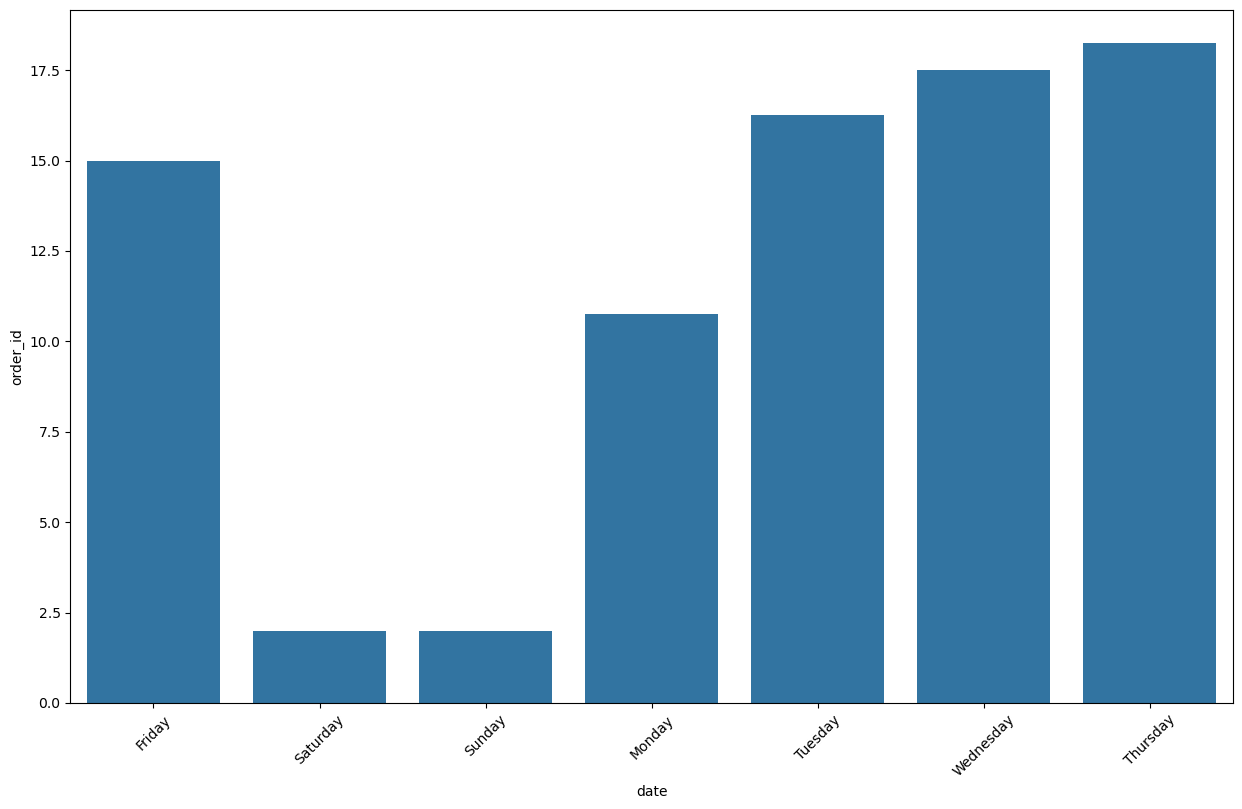

In [128]:
# Ваш код здесь
plt.figure(figsize=(15,9))
sns.barplot(data = orders_per_day, x =orders_per_day.date.dt.day_name(), y = orders_per_day.order_id, errorbar= None )
plt.xticks(rotation = 45 );

## Шаг 5

**Кажется, в данных помимо дня с наибольшим числом заказов есть еще один день, который выбивается из общей картины.** Что это за день:  
- Это воскресенье, в которое было много заказов?  
- Это понедельник, в который было много заказов?  
- Это пятница, в которую было мало заказов?  
- Это праздничный день, в который было мало заказов?

Подумайте, почему так вышло? Укажите этот день в том формате, в котором он представлен в данных (гггг-мм-дд)

In [134]:
orders_per_day['day_name'] = orders_per_day.date.dt.day_name()
orders_per_day.head()

,date,order_id,day_name
0,2024-03-01,22,Friday
1,2024-03-02,2,Saturday
2,2024-03-03,1,Sunday
3,2024-03-04,10,Monday
4,2024-03-05,18,Tuesday


In [142]:
orders_per_day['all_date'] = orders_per_day.date.dt.strftime('%Y-%m-%d')+ ' '+ orders_per_day.day_name
orders_per_day.head()

,date,order_id,day_name,all_date
0,2024-03-01,22,Friday,2024-03-01 Friday
1,2024-03-02,2,Saturday,2024-03-02 Saturday
2,2024-03-03,1,Sunday,2024-03-03 Sunday
3,2024-03-04,10,Monday,2024-03-04 Monday
4,2024-03-05,18,Tuesday,2024-03-05 Tuesday


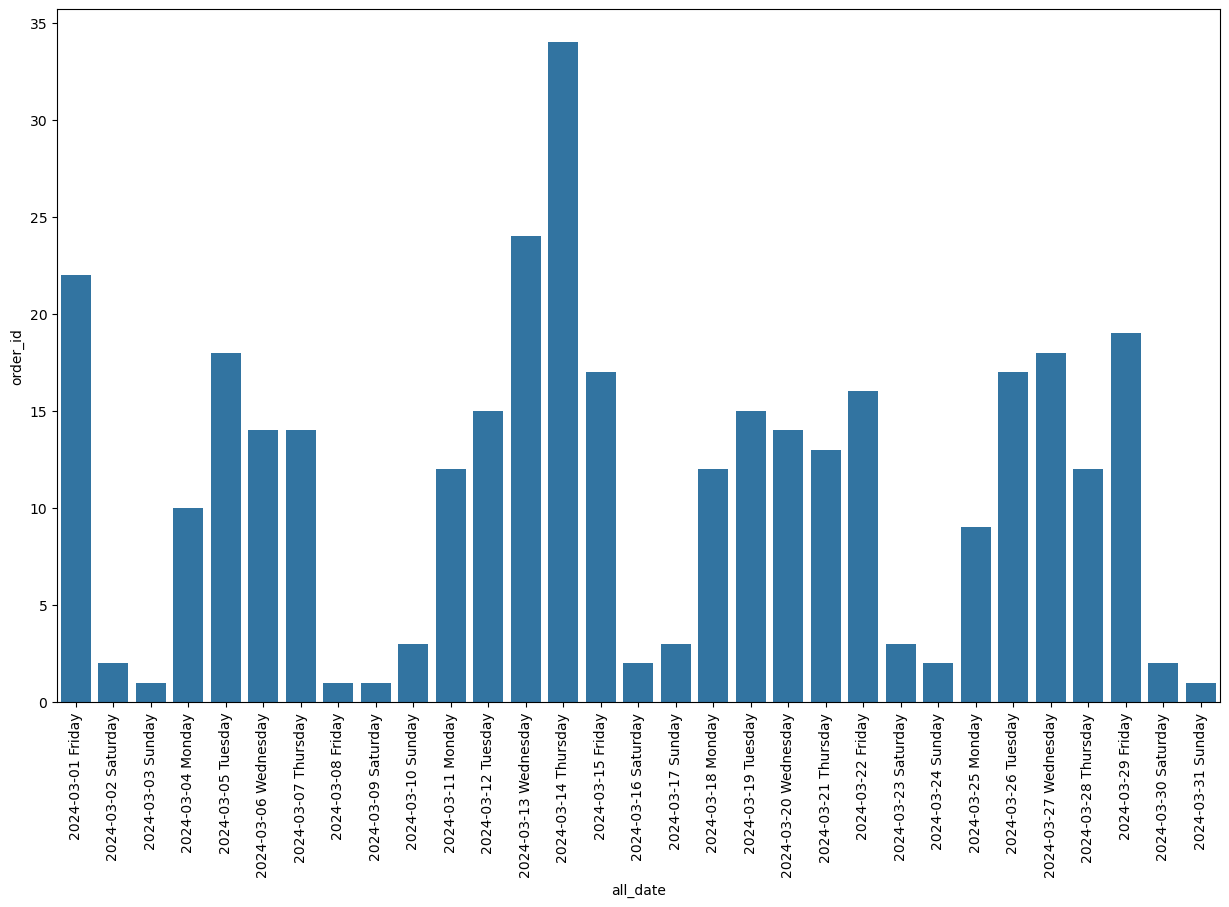

In [143]:
plt.figure(figsize=(15,9))
sns.barplot(data = orders_per_day, x =orders_per_day.all_date, y = orders_per_day.order_id, errorbar= None )
plt.xticks(rotation = 90 );

In [120]:
orders_per_day.loc[ orders_per_day.order_id.idxmax(), 'date']

Timestamp('2024-03-14 00:00:00')

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
Проверьте каждый из четырех предложенных поинтов: есть ли дни, соответствующие одному или нескольким поинтам? Посмотрите на график или на значения в датафрейме с количеством заказов по дням.
      
</p>
</details>

## Шаг 6

К вам пришел радостный руководитель отдела продаж и попросил выяснить причину, почему заказы в один из дней резко подскочили, чтобы и дальше увеличивать продажи.

Возможно, в день с наибольшим числом заказов (который вы определили на третьем шаге) отдел маркетинга запустил какую-то акцию? Или менеджеры стали активнее предлагать компаниям оформить заказ? Нужно подробнее изучить этот день. Начнем со статусов заказа.

**Добавьте к данным о заказах информацию об их статусах. Общий датафрейм назовите `orders_status`. Сохраните получившийся датафрейм в csv файл `orders_status.csv` (при сохранении используйте параметр `index=False`) и отправьте этот csv файл на проверку в LMS.**

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) Объедините датафреймы `df_orders` и `df_order_status` в новый `orders_status`.
      
2) Можете вывести первые строчки нового датафрейма и посмотреть его размер, чтобы убедиться, что объединение прошло корректно.
      
3) Сохраните датафрейм в csv файл с помощью метода, задав его название как строку `orders_status.csv` и параметр `index=False`.
      
4) Скачайте получившийся csv файл из той же папки в JupyterHub, где находится ноутбук, в котором вы пишете этот код. 
      
</p>
</details>

In [144]:
# Ваш код здесь
df_order_status.head()


,order_id,client_id,status
0,ABID-18767701,44,confirmed
1,ACXS-56511429,24,confirmed
2,AEDO-27030558,22,confirmed
3,AFIH-00611801,43,canceled
4,AFUU-55889181,88,confirmed


In [145]:
df_orders.head()

,order_id,product_id,quantity,date,manager
0,ABID-18767701,72,30,2024-03-11,Маргарита Камертонова
1,ABID-18767701,509,40,2024-03-11,Маргарита Камертонова
2,ABID-18767701,555,26,2024-03-11,Маргарита Камертонова
3,ABID-18767701,557,30,2024-03-11,Маргарита Камертонова
4,ABID-18767701,569,28,2024-03-11,Маргарита Камертонова


In [150]:
orders_status_for_answ = df_orders.merge(df_order_status, how='left', on = 'order_id')
orders_status_for_answ.client_id.sum()

np.int64(251232)

In [211]:
orders_status = df_orders.merge(df_order_status, how='left', on = 'order_id')
orders_status.head()

,order_id,product_id,quantity,date,manager,client_id,status
0,ABID-18767701,72,30,2024-03-11,Маргарита Камертонова,44,confirmed
1,ABID-18767701,509,40,2024-03-11,Маргарита Камертонова,44,confirmed
2,ABID-18767701,555,26,2024-03-11,Маргарита Камертонова,44,confirmed
3,ABID-18767701,557,30,2024-03-11,Маргарита Камертонова,44,confirmed
4,ABID-18767701,569,28,2024-03-11,Маргарита Камертонова,44,confirmed


In [212]:
orders_status.to_csv('orders_status.csv', index=False)

## Шаг 7

Посмотрите на количество и соотношение подтвержденных и отмененных заказов. **В ответе укажите долю отмененных заказов.** Ответ округлите до двух знаков после точки.

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) Чтобы оставить в данных только информацию о том, был заказ подтвержден или отменен, выберите из датафрейма `orders_status` колонки с номером заказа и статусом, а затем удалите дубликаты (НЕ сохраняйте результат в тот же датафрейм, потому что `orders_status` в полном виде понадобится для решения следующих заданий).

2) Посчитайте частоту, с которой встречается каждый из статусов в оставшихся данных.

3) Посчитайте долю каждого из статусов. Значения округлите до 2 знаков после точки.

      
</p>
</details>

In [213]:
# Ваш код здесь

orders_status.status.value_counts()

status
confirmed    4083
canceled      520
Name: count, dtype: int64

In [214]:
orders_status.status.value_counts(normalize=True).round(2)

status
confirmed    0.89
canceled     0.11
Name: proportion, dtype: float64

## Шаг 8

**Посчитайте количество подтвержденных и отмененных заказов на каждую дату.** Определите, в какой день не было ни одного подтвержденного заказа. Для этого сделайте сводную таблицу, где в строках будут даты, в колонках — стутасы заказов, а значения — число заказов с этим статусом в определенную дату. Пропуски заполните нулями.  

**В ответ укажите день, когда не было ни одного подтвержденного заказа.** Дату укажите в том формате, в котором она представлена в данных (гггг-мм-дд).

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) Данные в датафрейме `orders_status` сгруппируйте по дате и статусу, посчитайте количество уникальных заказов для каждой группы. Получившуюся колонку с числом заказов можете переименовать в `orders`.
      
2) Разверните получившийся датафрейм так, чтобы получилась сводная таблица, где в индексе — даты, в колонках — статусы, а в значениях — количество заказов. 
      
3) Пропуски заполните нулями.
      
4) Из-за того, что после разворота таблицы в колонках `canceled` и `confirmed` появились пропущенные значения, тип данных в этих колонках стал `float`. Но число заказов не может быть дробным, поэтому приведите эти колонки к типу `int`.
      
5) Отфильтруйте строки, где значение в колонке `confirmed` равно нулю.
      
</p>
</details>

In [215]:
# Ваш код здесь
orders_status.groupby(['date','status'], as_index=False).agg({'order_id':'count'}) \
             .rename(columns={'order_id':'number_of_orders'}) \
             .pivot(columns='status', index='date', values='number_of_orders') \
             .fillna(0).query('confirmed == 0')


status,canceled,confirmed
date,,
2024-03-09,18.0,0.0


## Шаг 9

**Постройте график с заказами по дням в разбивке по статусу заказа.** Посмотрим подробнее на день с наибольшим числом заказов (вместе и подтвержденных, и отменных), который мы определили ранее, и на день, предшествующий ему. Какой вывод можно сделать? Выберите один или несколько вариантов:

- В день с наибольшим числом заказов было очень много отмен  
- В день с наибольшим числом заказов было много успешно оформленных заказов  
- В день, предшествующий дню с наибольшим числом заказов, было много отмен  
- В день, предшествующий дню с наибольшим числом заказов, было много успешно оформленных заказов  
- В день, предшествующий дню с наибольшим числом заказов, не было ни одного успешно оформленного заказа  
- В день, предшествующий дню с наибольшим числом заказов, не было ни одного отмененного заказа

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
Постройте линейный график, где по оси `х` будут идти даты, по оси `у` — количество заказов, а цвета линий будут определены статусами заказов. Если метки с датами наползают друг на друга, поверните их под углом 45 градусов.

</p>
</details>

In [216]:
date_by_status = orders_status.groupby(['date','status'], as_index=False).agg({'order_id':'count'}) \
                              .rename(columns={'order_id':'number_of_orders'}) 
                              
date_by_status = date_by_status.assign(date_all = date_by_status.date.dt.strftime('%Y-%m-%d') +' '+ orders_status.date.dt.day_name())
date_by_status.head()

,date,status,number_of_orders,date_all
0,2024-03-01,canceled,29,2024-03-01 Monday
1,2024-03-01,confirmed,273,2024-03-01 Monday
2,2024-03-02,confirmed,30,2024-03-02 Monday
3,2024-03-03,confirmed,8,2024-03-03 Monday
4,2024-03-04,confirmed,143,2024-03-04 Monday


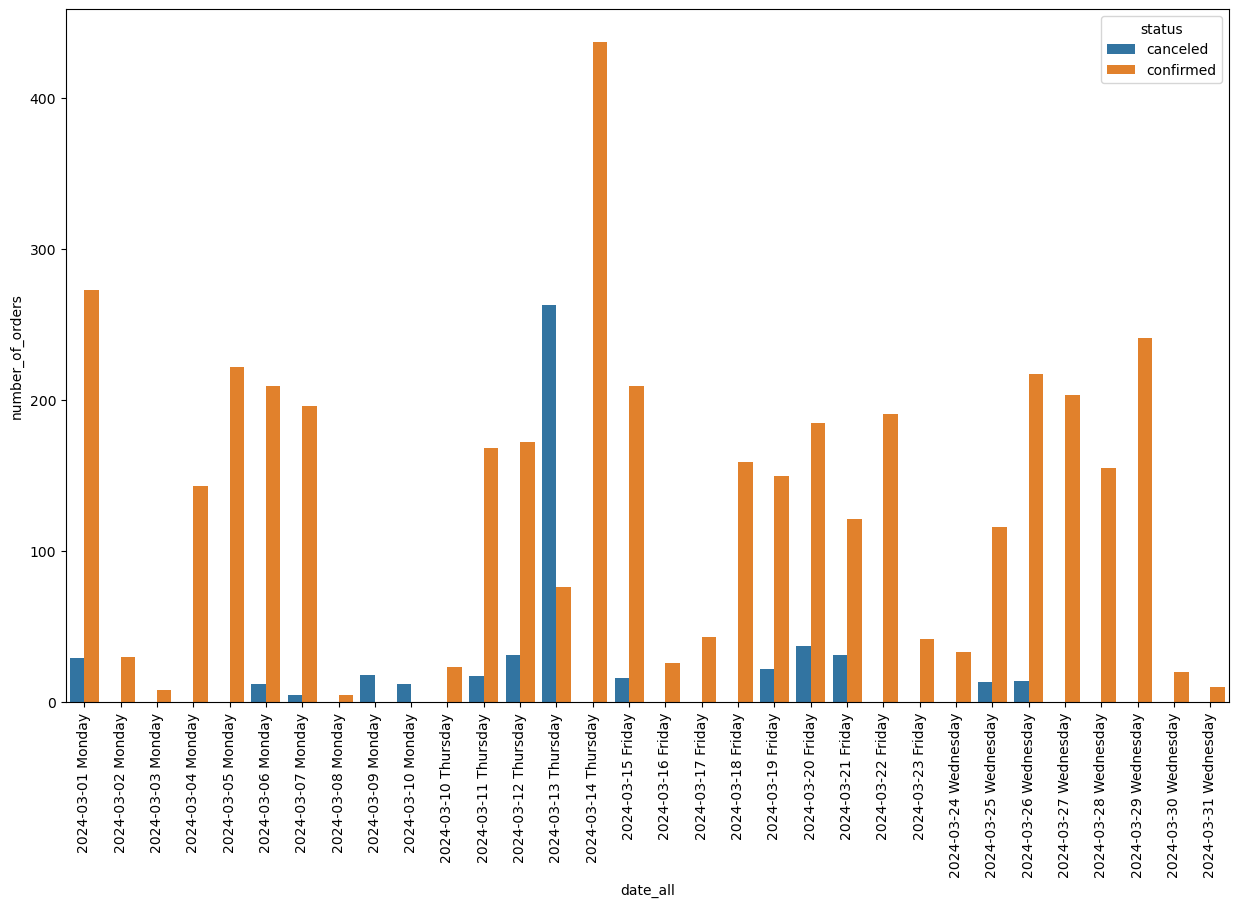

In [217]:
# Ваш код здесь
plt.figure(figsize=(15,9))
sns.barplot(data = date_by_status, x = 'date_all', y = 'number_of_orders', hue='status', estimator='sum')
plt.xticks(rotation = 90 );

## Шаг 10

Рассмотрим эти два дня отдельно (день с наибольшим числом заказов, который мы определили ранее, и день, предшествующий ему). Проанализируйте заказы за эти дни и ответьте, какую из этих гипотез можно назвать наиболее правдоподобной.

- Так сложилось, что один день оказался крайне неудачным для отдела продаж, все клиенты отменили свои заказы. А на следующий день отдел продаж пытался компенсировать отсутствие продаж в предыдущий и перевыполнил дневной план. Почти все заказы не повторяют вчерашние  
- Произошел сбой в работе CRM системы, который не позволил клиентам подтвердить заказ. В результате все созданные в первый день заказы автоматически отменились, поэтому клиентам пришлось оформлять их повторно на следующий день. Почти половина заказов повторяет вчерашние

Как можно определить, что заказ повторяет вчерашний? У заказов будут совпадать сразу несколько параметров: клиент, менеджер, количество уникальных товаров в заказе и общее число товаров в штуках. Но номера заказов будут разными.

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) Отберите все отмененные заказы 13 марта и для каждого заказа агрегируйте данные: посчитайте количество уникальных товаров в нем, сумму единиц всех товаров, а также возьмите менеджера и клиента (примените к соответствующим колонкам функции `max`).
      
2) Отберите все подтвержденные заказы 14 марта и для каждого заказа агрегируйте данные: посчитайте количество уникальных товаров в нем, сумму единиц всех товаров, а также возьмите менеджера и клиента (примените к соответствующим колонкам функции `max`).
      
3) Объедините эти датафреймы с заказами по совпадающим характеристикам: имя менеджера, id клиента, число уникальных товаров в заказе и общее число товаров в штуках. Так у вас получатся те заказы, которые отменили в первый день и оформили заново на следующий.
      
4) Посчитайте число строк в датафрейме с заказами, которые отменили в первый день и оформили заново на следующий. Разделите это число на число строк в датафрейме с подтвержденными заказами 14 марта. Так вы узнаете долю заказов, которые повторяют вчерашние.
      
</p>
</details>

In [229]:
# Ваш код здесь
strange_date_2024_03_13 = pd.to_datetime("2024-03-13")
strange_date_2024_03_14 = pd.to_datetime("2024-03-14")

orders_status_2024_03_13_canceled = orders_status.query('(date == @strange_date_2024_03_13 ) and (status == "canceled")')
orders_status_2024_03_14_confirmed = orders_status.query('(date == @strange_date_2024_03_14 ) and (status == "confirmed")')
orders_status_2024_03_13_canceled.head()

,order_id,product_id,quantity,date,manager,client_id,status
34,AFIH-00611801,17,26,2024-03-13,Алексей Саксофонов,43,canceled
35,AFIH-00611801,240,21,2024-03-13,Алексей Саксофонов,43,canceled
36,AFIH-00611801,468,5,2024-03-13,Алексей Саксофонов,43,canceled
37,AFIH-00611801,505,28,2024-03-13,Алексей Саксофонов,43,canceled
38,AFIH-00611801,511,13,2024-03-13,Алексей Саксофонов,43,canceled


In [254]:
canceled_2024_03_13 = orders_status_2024_03_13_canceled.groupby('order_id', as_index=False).agg(
                                                         unique_products=('product_id', 'nunique'), 
                                                         total_quantity = ('quantity','sum'), 
                                                         manager=('manager', 'max'),
                                                         client=('client_id', 'max') )
canceled_2024_03_13.head()

,order_id,unique_products,total_quantity,manager,client
0,AFIH-00611801,11,192,Алексей Саксофонов,43
1,BBFJ-27674101,14,294,Ксения Балалайкина,73
2,CLBQ-63032648,13,205,Виктор Тромбонов,60
3,CYJY-07359557,13,316,Екатерина Тарелкина,56
4,GHGB-88045656,4,42,Ксения Балалайкина,7


In [255]:
confirmed_2024_03_14 = orders_status_2024_03_14_confirmed.groupby('order_id', as_index=False).agg(
                                                         unique_products=('product_id', 'nunique'), 
                                                         total_quantity = ('quantity','sum'), 
                                                         manager=('manager', 'max'),
                                                         client=('client_id', 'max') )
confirmed_2024_03_14.head()

,order_id,unique_products,total_quantity,manager,client
0,ACXS-56511429,8,177,Алексей Саксофонов,24
1,AUZX-12706022,19,369,Екатерина Тарелкина,83
2,BCMM-97072924,17,325,Алексей Саксофонов,51
3,BGHE-44722549,8,149,Виктор Тромбонов,95
4,DMEB-71700015,12,190,Сергей Контрабасов,93


In [253]:
repeat_orders = confirmed_2024_03_14.merge(canceled_2024_03_13, on= ['unique_products', 'total_quantity' ,'manager', 'client'], how='inner')
result = round( len(repeat_orders)/len(confirmed_2024_03_14), 2)
result

0.47

### Посчитаем ключевые метрики, посмотрим на их динамику и составим небольшой отчет

## Шаг 11

**У вас есть данные за целый месяц, поэтому пора посчитать ключевые метрики этого месяца.** Но вот незадача - в ваших данных цена единицы товара указана в долларах США, потому что закупаете их в долларах, но продаете товары за российские рубли (по тому курсу, который установил Центробанк на дату продажи), а значит и метрики требуется посчитать в рублях. Хорошо, что у вас есть текстовый файл с курсом доллара США на каждую дату. **Откройте файл `usd_rate.txt`, соберите из него датафрейм с 2 колонками: `date` и `currency_rate`. Посчитайте среднее значение курса доллара за месяц.** Результат округлите до двух знаков после точки.

In [272]:
# Ваш код здесь
file = open('usd_rate.txt')
date_list = []
currency_rate_list = []
for line in file.readlines():
    date_list.append( pd.to_datetime(line.split(',')[0]) )
    currency_rate_list.append( float(line.split(',')[1]) )
usd_rate = pd.DataFrame( { 'date' : date_list ,
                            'currency_rate' : currency_rate_list
                         })
usd_rate.currency_rate.mean().round(2)

np.float64(91.7)

## Шаг 12

**Работу с ключевыми метриками начните с подсчета общей выручки.** Данные по товарам в подтвержденных заказах у вас есть в датафрейме `orders_status`, а стоимость одной единицы товара можно взять из датафрейма `df_products`. Объедините эти датафреймы в общий `df_full`, добавьте к ним информацию по курсу доллара на каждую дату. Создайте колонку с выручкой для каждого товара в заказах и посчитайте, **чему равна общая выручка в рублях?** Учитывайте только подтвержденные заказы. Результат округлите до двух знаков после точки.

In [273]:
orders_status.head(1)

,order_id,product_id,quantity,date,manager,client_id,status
0,ABID-18767701,72,30,2024-03-11,Маргарита Камертонова,44,confirmed


In [274]:
df_products.head(1)

,id,name,price,category
0,1,"AKG, D5",180.46,Динамический микрофон


<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) Присоедините к датафрейму `orders_status` датафрейм `df_products`, указав, что ключом в левом датафрейме будет являться колонка `product_id` (параметр `left_on`), а в правом — колонка `id` (параметр `right_on`). Новый датафрейм сохраните в `df_full`.
      
2) К датафрейму `df_full` добавьте информацию о курсе доллара на каждую дату, присоединив датафрейм `df_currency` по общей колонке с датой.
      
3) Создайте колонку `price_rub` с ценами в рублях. Для этого умножьте значения в колонке `price` с ценами на значения в колонке `currency_rate` с курсом валюты.
      
4) Создайте колонку `revenue` с выручкой, умножив колонку со стоимостью единицы товара в рублях на колонку с количеством товара.
      
5) Отберите только записи с подтвержденными заказами и сохраните результат в датафрейм `df_confirmed`, он вам ещё пригодится.
      
6) Суммируйте значения в колонке `revenue` и округлите результат до двух знаков после точки.
      
</p>
</details>

In [276]:
# Ваш код здесь
df_full = pd.merge(orders_status, df_products, left_on='product_id', right_on='id', how='left') \
            .merge(usd_rate, on = 'date', how = 'left')
df_full.head()

,order_id,product_id,quantity,date,manager,client_id,status,id,name,price,category,currency_rate
0,ABID-18767701,72,30,2024-03-11,Маргарита Камертонова,44,confirmed,72,"Beyerdynamic, DT 990 PRO",158.91,Проводные наушники,90.7493
1,ABID-18767701,509,40,2024-03-11,Маргарита Камертонова,44,confirmed,509,"Heco, Stay 300",43.95,Проводные наушники,90.7493
2,ABID-18767701,555,26,2024-03-11,Маргарита Камертонова,44,confirmed,555,"JBL, Charge 4",159.13,Беспроводная акустика,90.7493
3,ABID-18767701,557,30,2024-03-11,Маргарита Камертонова,44,confirmed,557,"JBL, Xtreme 2",308.70,Беспроводная акустика,90.7493
4,ABID-18767701,569,28,2024-03-11,Маргарита Камертонова,44,confirmed,569,"JBL, Live 650BTNC",178.47,Беспроводные наушники,90.7493


In [281]:
df_full['total_cost_rub'] = df_full.quantity * df_full.price * df_full.currency_rate
total_revenue = df_full.query('status == "confirmed"').total_cost_rub.sum()
total_revenue.round(2)

np.float64(2038231821.56)

## Шаг 13

**Следующая метрика, которую вам нужно посчитать — средний чек в этом месяце (в рублях).** Разделите общую выручку на количество заказов. Результат округлите до двух знаков после точки.

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) Посчитайте число уникальных подтвержденных заказов.

2) Разделите сумму выручки, посчитанную на прошлом шаге (без округления), на это число.

3) Результат округлите до двух знаков после точки.  
      
</p>
</details>

In [285]:
# Ваш код здесь
number_of_orders = df_full.query('status == "confirmed"').order_id.nunique()
average_bill = total_revenue/number_of_orders
average_bill.round(2)

np.float64(6596219.49)

## Шаг 14

Ключевые метрики месяца вы посчитали, теперь попробуйте посмотреть на их динамику внутри месяца: посчитайте выручку, средний чек и число заказов — на каждый день. Посмотрите на графики и выберите верные ответы:

- число заказов и выручка каждый день изменяются в одинаковом направлении (если в этот день число заказов выросло, то и выручка выросла; число заказов упало — в этот же день упала и выручка)  
- число заказов и выручка не каждый день изменяются в одинаковом направлении (если в какой-то день число заказов выросло, то выручка может упасть, и наоборот: число заказов упало — в этот же день выручка выросла)  
- средний чек и выручка каждый день изменяются в одинаковом направлении (если в этот день средний чек вырос, то и выручка выросла; средний чек упал — в этот же день упала и выручка)  
- средний чек и выручка не каждый день изменяются в одинаковом направлении (если в какой-то день средний чек вырос, то выручка может упасть, и наоборот: средний чек упал — в этот же день выручка выросла)  
- в день с наибольшим числом заказов и выручка, и средний чек также показывают максимальное значение  
- в день с наибольшим числом заказов выручка и/или средний чек не показывают максимальное значение  
- с течением времени выручка то увеличивается, то уменьшается  
- с течением времени выручка только увеличивается  
- на протяжении всего месяца средний чек то увеличивается, то уменьшается  
- средний чек на протяжении всего месяца имеет одинаковое значение

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) Сгруппируйте датафрейм `df_confirmed` с подтвержденными заказами по дате и посчитайте на каждую дату число ункальных заказов и выручку. Результат сохраните в датафрейм `df_report_by_date`. Получившуюся колонку с числом заказов можете переименовать в `orders`. 
      
2) Создайте колонку со значением среднего чека в каждую дату, для этого разделите значения в колонке с выручкой на значения в колонке с числом заказов. Результат округлите до двух знаков после точки
      
3) Постройте три линейных графика, один под другим (в одной ячейке или в разных)
      
</p>
</details>

In [298]:
# Ваш код здесь
df_report_by_date = df_full.query('status == "confirmed"').groupby('date', as_index=False) \
                           .agg( total_order_per_day = ( 'order_id', 'nunique' ),
                                 revenue_per_day = ('total_cost_rub', 'sum') ) \
                           .assign(average_bill_per_day = lambda df : df.revenue_per_day/ df.total_order_per_day)
df_report_by_date.head()

,date,total_order_per_day,revenue_per_day,average_bill_per_day
0,2024-03-01,20,1.554118e+08,7.770588e+06
1,2024-03-02,2,1.197167e+07,5.985834e+06
2,2024-03-03,1,2.548418e+06,2.548418e+06
3,2024-03-04,10,6.404993e+07,6.404993e+06
4,2024-03-05,18,8.952724e+07,4.973735e+06


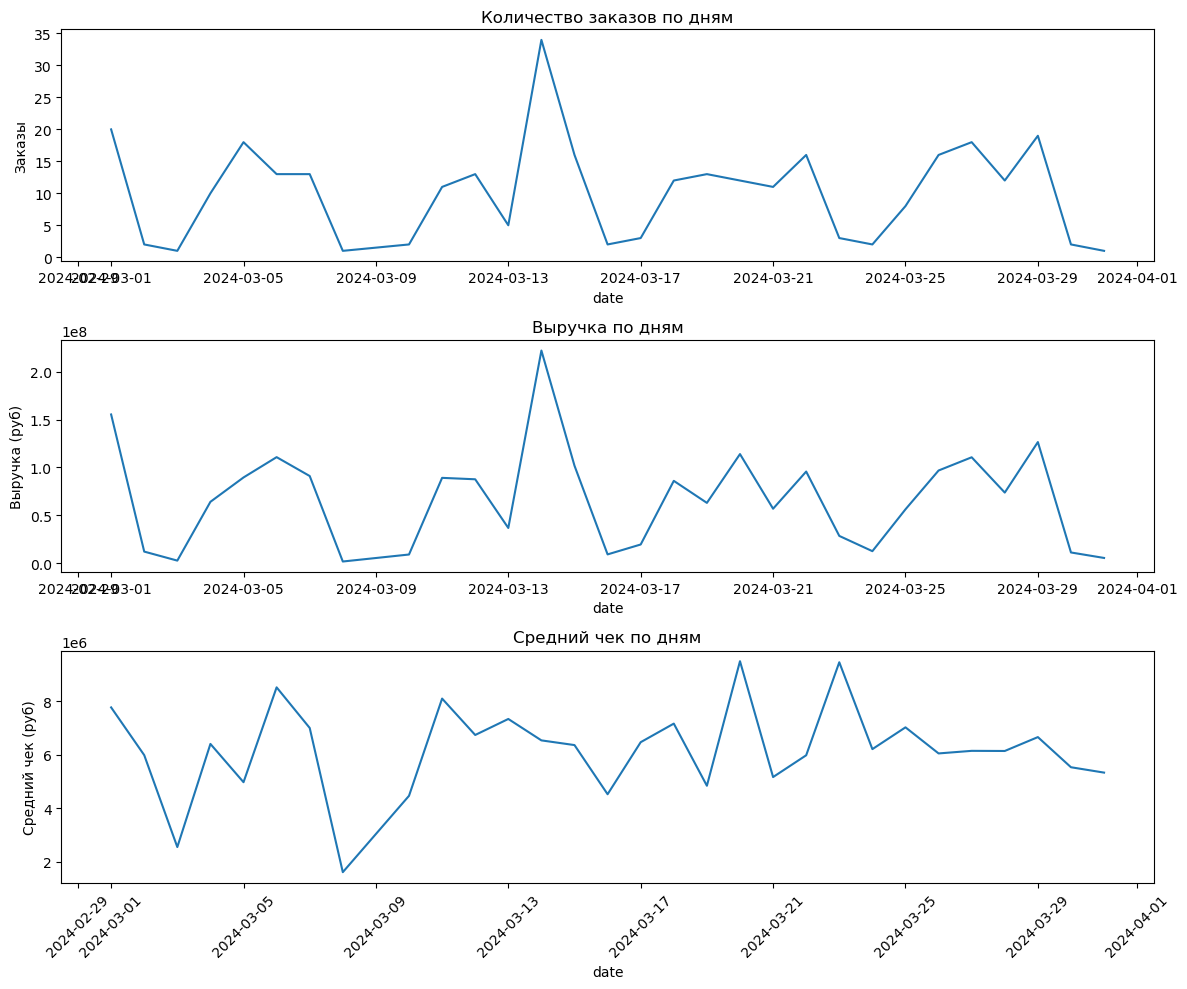

In [305]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

sns.lineplot(data=df_report_by_date, x='date', y='total_order_per_day', ax=axes[0])
axes[0].set_title('Количество заказов по дням')
axes[0].set_ylabel('Заказы')

sns.lineplot(data=df_report_by_date, x='date', y='revenue_per_day', ax=axes[1])
axes[1].set_title('Выручка по дням')
axes[1].set_ylabel('Выручка (руб)')

sns.lineplot(data=df_report_by_date, x='date', y='average_bill_per_day', ax=axes[2])
axes[2].set_title('Средний чек по дням')
axes[2].set_ylabel('Средний чек (руб)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Проанализируем интерес клиентов к брендам

## Шаг 15

К вам снова обратился руководитель отдела продаж. Он хочет разобраться, какие бренды востребованы среди клиентов, а какие — нет. На основе данных о названиях товаров в датафрейме `df_full` создайте новую колонку `brand`, где будет только название бренда. **Посчитайте, сколькими брендами интересовались клиенты** (статус заказа здесь не важен, если запись о бренде попала в данные о заказах, значит клиент заказал или хотел заказать товар этого бренда).

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) В датафрейме `df_full` создайте новую колонку `brand`, в которую поместите только названия брендов. Для этого разделите значения в колонке name и возьмите первое из них (сначала идет бренд и через запятую модель товара).

2) Посчитайте количество уникальных значений в колонке `brand`.
      
</p>
</details>

In [311]:
# Ваш код здесь
df_full['brand'] = df_full.name.apply(lambda x: x.split(',')[0])
df_full.brand.nunique()


121

## Шаг 16

Посчитайте, какую выручку принес каждый бренд и в скольких подтвержденных заказах были товары этого бренда. **Определите, какой бренд принес наибольшую выручку.** В ответ укажите его название.

Дополнительно: проверьте, именно этот бренд встречается в большем количестве заказов, чем другие бренды? Или может его реже заказывают, но на более крупные суммы?

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) Отберите в датафрейме `df_full` только подтвержденные заказы.

2) Сгруппируйте данные по брендам и посчитайте выручку и количество уникальных заказов.

3) Отсортируйте агрегированные данные по убыванию выручки и посмотрите бренд в верхней строчке.

4) Дополнительно: отсортируйте агрегированные данные по убыванию количество заказов и посмотрите бренд в верхней строчке.

</p>
</details>

In [312]:
df_full.head()

,order_id,product_id,quantity,date,manager,client_id,status,id,name,price,category,currency_rate,total_cost_rub,brand
0,ABID-18767701,72,30,2024-03-11,Маргарита Камертонова,44,confirmed,72,"Beyerdynamic, DT 990 PRO",158.91,Проводные наушники,90.7493,432629.137890,Beyerdynamic
1,ABID-18767701,509,40,2024-03-11,Маргарита Камертонова,44,confirmed,509,"Heco, Stay 300",43.95,Проводные наушники,90.7493,159537.269400,Heco
2,ABID-18767701,555,26,2024-03-11,Маргарита Камертонова,44,confirmed,555,"JBL, Charge 4",159.13,Беспроводная акустика,90.7493,375464.338834,JBL
3,ABID-18767701,557,30,2024-03-11,Маргарита Камертонова,44,confirmed,557,"JBL, Xtreme 2",308.70,Беспроводная акустика,90.7493,840429.267300,JBL
4,ABID-18767701,569,28,2024-03-11,Маргарита Камертонова,44,confirmed,569,"JBL, Live 650BTNC",178.47,Беспроводные наушники,90.7493,453488.771988,JBL


In [324]:
# Ваш код здесь
df_brand = df_full.query('status == "confirmed"').groupby('brand', as_index=False) \
                  .agg(cost_rub_per_brand = ('total_cost_rub', 'sum'),
                       count_confirmed = ('status', 'size'))
df_brand.loc[df_brand.cost_rub_per_brand.idxmax(), 'brand']

'JBL'

In [325]:
df_brand.query('brand == "JBL"')

,brand,cost_rub_per_brand,count_confirmed
46,JBL,2.665961e+08,592


In [327]:
df_brand.count_confirmed.mean()

np.float64(33.743801652892564)

## Шаг 17

У одних брендов большинство товаров востребовано клиентами, а у других — клиенты заказывают только небольшую часть товаров, а остальные зря занимают виртуальную «полку» в перечне товаров, продаваемых вашей компанией. **Вам нужно определить, какие бренды редко попадают в заказы, хотя товаров таких брендов на самом деле много.**

Начнем с того, что определим, какие товары из имеющихся в продаже хоть раз заказывали, а какие — нет. Для этого соберите список из перечня уникальных идентификаторов товаров, которые встречаются в датафрейме `df_confirmed`. После этого для каждого товара в датафрейме `df_products` определите, был ли этот товар в списке заказанных товаров в этом месяце или нет: создайте новую колонку `is_in_orders` и заполните её соответственно значениями `yes` или `no` для каждого товара.

**В ответе укажите, сколько товаров были заказаны, а сколько — не были**

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
      
1) Сохраните в список `products_in_orders` уникальные идентификаторы товаров из датафрейма `df_confirmed`.
      
2) Создайте в датафрейме `df_products` новую колонку `is_in_orders`, в которой будет значение `yes`, если значение из колонки `id` этого датафрейма есть в списке `products_in_orders`. Если его в этом списке нет - в новую колонку для этой строчки запишите значение `no`.
      
3) Посчитайте количество встречающихся значений `yes` и  `no` в колонке `is_in_orders`.
      
</p>
</details>

In [339]:
# Ваш код здесь
df_confirmed = df_full.query('status == "confirmed"')
product_id_in_orders = df_confirmed.product_id.unique()
df_products['is_in_orders'] = df_products.id.apply( lambda x: 'yes' if x in product_id_in_orders else 'no') 
df_products.is_in_orders.value_counts()

is_in_orders
yes    1180
no      497
Name: count, dtype: int64

## Шаг 18

Примерно треть товаров не была заказана ни разу в этом месяце. Посмотрим на эти данные в разрезе по брендам. **Определите, у каких брендов доля ни разу не заказанных товаров была больше половины от всех продаваемых товаров этого бренда.** Но не берите в расчет бренды, которые представлены маленьким числом товаров (меньше 15), они не захламляют виртуальную «полку».

Отметьте бренды, у которых доля ни разу не заказанных товаров была больше половины от всех продаваемых товаров этого бренда: 
- AKG  
- ASUS	
- Dali  
- Emotiva  
- KEF  
- Marantz  
- Onkyo  
- Pioneer  
- Yaqin

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
       
1) В датафрейме `df_products` создайте новую колонку `brand`, в которую поместите только названия брендов. Для этого разделите значения в колонке `name` и возьмите первое из них (сначала идет бренд и через запятую модель товара).
      
2) Сгруппируйте данные по бренду и колонке, в которой указано, есть товар в заказах, и посчитайте число уникальных товаров. Колонку с числом товаров можете переименовать в `products`.
      
3) Разверните сгруппированные данные так, чтобы получилась сводная таблица в которой в индексе названия брендов, в колонках - есть товар в заказах или нет (`yes` и `no`), в значениях - количество товаров.
      
4) Заполните пропуски нулями.
      
5) Сбросьте индекс, чтобы названия брендов стали колонкой.
      
6) Посчитайте общее число товаров для каждого бренда, сложив значения в колонках `yes` и `no`.
      
7) Для каждого бренда посчитайте долю ни разу не заказанных товаров от всех продаваемых товаров этого бренда.
      
8) Отберите только те бренды, где общее число товаров больше 15 и доля ни разу не заказанных товаров больше половины (0.5).
      
</p>
</details>

In [345]:
# Ваш код здесь
df_products_with_brand = df_products.copy()
df_products_with_brand['brand'] = df_products_with_brand.name.apply(lambda x: x.split(',')[0])
df_products_with_brand.head()

,id,name,price,category,is_in_orders,brand
0,1,"AKG, D5",180.46,Динамический микрофон,no,AKG
1,2,"AKG, D40",85.80,Динамический микрофон,yes,AKG
2,3,"AKG, C414 XLII",935.11,Конденсаторный микрофон,no,AKG
3,4,"AKG, C214",356.02,Конденсаторный микрофон,yes,AKG
4,5,"AKG, P120",86.13,Конденсаторный микрофон,no,AKG


In [359]:
big_brands = df_products_with_brand.groupby('brand').id.count().reset_index() \
                                   .rename(columns = {'id':'all_products_count'}) \
                                   .query('all_products_count >= 15 ')
big_brands.head()

,brand,all_products_count
5,Anker,15
17,Bose,21
32,Dali,67
36,Denon,41
39,Edifier,73


In [360]:
df_products_with_brand[df_products_with_brand.brand.isin(big_brands.brand)] \
                      .groupby('brand').is_in_orders.value_counts(normalize= True).reset_index() \
                      .pivot(values = 'proportion', columns = 'is_in_orders', index= 'brand') \
                      .query('no > 0.5')

is_in_orders,no,yes
brand,,
Dali,0.731343,0.268657
KEF,0.658537,0.341463
Marantz,0.863636,0.136364
Pioneer,0.679612,0.320388


### Составим отчет по продажам менеджеров

## Шаг 19

Чтобы компания знала, кого из менеджеров отдела продаж премировать, а с кем провести беседу по итогам месяца, **вас попросили сделать отчет по сделкам каждого менеджера**: сколько он оформил подтвержденных заказов и какую выручку они принесли. Но в абсолютных числах вклад каждого сотрудника может быть непонятен. **Поэтому посчитайте значения в процентах: какой % выручки от общей выручки за месяц приходится на каждого менеджера, и какой % заказов от общего числа заказов.** Посчитайте данные и визуализируйте результат, чтобы принимать решение о поощрении или проведении беседы с менеджерами было удобнее. Выберите верные ответы:

- лучшим менеджером по % выручки стала Маргарита Камертонова  
- лучшим менеджером по % заказов стала Маргарита Камертонова  
- первая пятерка менеджеров по % выручки сильно ушла вперед от всех остальных (явно виден большой разрыв между каждым из первой пятерки и каждым из всех остальных менеджеров)  
- в этом месяце нельзя выделить явную пятерку лидеров по % выручки, которые сильно оторвались от остальных  
- лидер по % заказов реализовал более 16% заказов  
- лидер по % заказов реализовал менее 16% заказов  
- наихудшие показатели у Сергея Контрабасова  
- наихудшие показатели у Аркадия Октавина  
- Антон Скрипкин принес в 3 раза меньше выручки, чем Виктор Тромбонов  
- Антон Скрипкин реализовал почти в 3 раза меньше заказов, чем Анастасия Дудкина

<details>
<summary>&#9658; Нажмите сюда, чтобы увидеть подсказку</summary>
  <p>
       
1) Сгруппируйте данные с подтвержденными заказами из датафрейма `df_confirmed` по менеджерам и посчитайте для каждого сумму выручки и количество заказов. Получившуюся колонку с числом заказов можете переименовать в `orders`.
      
2) Отсортируйте записи по убыванию выручки.
      
3) Посчитайте процент выручки, приходящейся на каждого менеджера: разделите его выручку на суммарную выручку всех менеджеров и умножьте результат на 100. Округлите до двух знаков после точки.
      
4) Посчитайте процент заказов, приходящихся на каждого менеджера: разделите его число заказов на суммарное число заказов всех менеджеров и умножьте результат на 100. Округлите до двух знаков после точки.   
      
5) Постройте два барплота (столбиковые диаграммы): со значениями % выручки и % заказов у каждого менеджера.
      
</p>
</details>

In [370]:
# Ваш код здесь
df_confirmed.head(1)

,order_id,product_id,quantity,date,manager,client_id,status,id,name,price,category,currency_rate,total_cost_rub,brand
0,ABID-18767701,72,30,2024-03-11,Маргарита Камертонова,44,confirmed,72,"Beyerdynamic, DT 990 PRO",158.91,Проводные наушники,90.7493,432629.13789,Beyerdynamic


In [389]:
all_total_cost_rub = df_confirmed.total_cost_rub.sum()
all_confirmed_status = df_confirmed.status.count()
manager_report = df_confirmed.groupby('manager', as_index=False).agg(
                                                total_cost_rub_by_one  = ('total_cost_rub' , 'sum'),
                                                total_confirmed_by_one = ('status', 'count') )
manager_report['cost_by_one_percent'] = round(manager_report.total_cost_rub_by_one / all_total_cost_rub * 100, 2)
manager_report['confirmed_by_one_percent'] = round(manager_report.total_confirmed_by_one / all_confirmed_status * 100, 2)
sorted_manager_report = manager_report.sort_values(['cost_by_one_percent','confirmed_by_one_percent'], ascending=False)
sorted_manager_report

,manager,total_cost_rub_by_one,total_confirmed_by_one,cost_by_one_percent,confirmed_by_one_percent
9,Маргарита Камертонова,3.473886e+08,678,17.04,16.61
4,Виктор Тромбонов,3.188999e+08,641,15.65,15.70
8,Максим Барабанов,2.401478e+08,502,11.78,12.29
5,Владимир Ударников,2.084865e+08,423,10.23,10.36
0,Алексей Саксофонов,1.953435e+08,391,9.58,9.58
7,Ксения Балалайкина,1.817621e+08,341,8.92,8.35
6,Екатерина Тарелкина,1.781576e+08,356,8.74,8.72
10,Надежда Гармошкина,1.347836e+08,254,6.61,6.22
1,Анастасия Дудкина,1.234504e+08,271,6.06,6.64
2,Антон Скрипкин,5.150268e+07,98,2.53,2.40


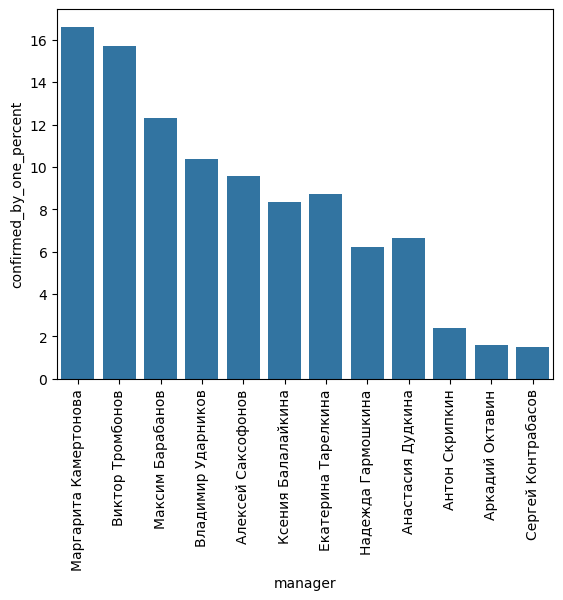

In [386]:
sns.barplot(data = sorted_manager_report, x = 'manager', y ='confirmed_by_one_percent')
plt.xticks(rotation = 90);

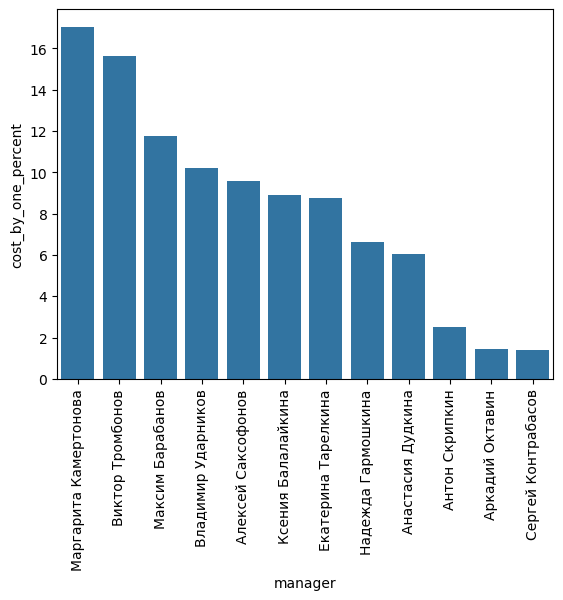

In [387]:
sns.barplot(data = sorted_manager_report, x = 'manager', y ='cost_by_one_percent')
plt.xticks(rotation = 90);

## Итоги

В финальном проекте модуля Python вы проанализировали продажи музыкальных товаров: собрали данные, посчитали ключевые метрики в динамике; определили дни, которые выбиваются из общей картины, и выяснили причину этого; нашли наиболее прибыльные бренды и те, которые зря занимают место на виртуальной «полке». Вы проделали отличную работу!

Но если считаете, что можете больше, продолжайте анализ имеющихся данных самостоятельно. Например, посмотрите, в какие дни недели оформляется в среднем больше заказов; составьте более полный отчет по продажам каждого менеджера (учтите отмененные заказы); определите наиболее и наименее популярные/прибыльные категории товаров и т.п. Данные полны инсайтов! Но эти задания не оцениваются и по ним не осуществляется поддержка экспертов. Зато вы можете сделать эту работу своим пет-проектом :)